# Проект\. Часть 4

## HR Analytics: Employee Attrition & Performance

Источник \(данные не менялись\): Kaggle https://www\.kaggle\.com/datasets/pavansubhasht/ibm\-hr\-analytics\-attrition\-dataset/data 

Цель проекта: исследовать факторы, влияющие на текучесть кадров \(Attrition\) и определить, какие характеристики сотрудников повышают вероятность их ухода из компании\.

**Задача для предсказания:** предсказать, уйдёт ли сотрудник из компании, основываясь на данных о нём и его работе

Эта задача напрямую связана с основной целью проекта, так как, во-первых, может помочь предотвратить текучесть кадров, а во-вторых, дерево решений может помочь понять, какие характеристики сотрудников приводили к уходу из компании. Это задача классификации (классы "No" и "Yes").

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

from sklearn.model_selection import train_test_split
from sklearn import metrics

Загрузка данных, удаление лишних колонок и преобразование категориальных переменных:

In [2]:
data = pd.read_csv("datasets/HR-Employee-Attrition.csv")
columns_to_drop = ['EducationField', 'JobRole', 'PerformanceRating', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours', 'HourlyRate', 'MonthlyRate']
data = data.drop(columns=columns_to_drop)
data = pd.get_dummies(data, columns = ['Attrition', 'BusinessTravel', 'Department', 'Gender', 'OverTime', 'MaritalStatus'], drop_first=True)
data

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,...,YearsWithCurrManager,Attrition_Yes,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,Gender_Male,OverTime_Yes,MaritalStatus_Married,MaritalStatus_Single
0,41,1102,1,2,2,3,2,4,5993,8,...,5,True,False,True,False,True,False,True,False,True
1,49,279,8,1,3,2,2,2,5130,1,...,7,False,True,False,True,False,True,False,True,False
2,37,1373,2,2,4,2,1,3,2090,6,...,0,True,False,True,True,False,True,True,False,True
3,33,1392,3,4,4,3,1,3,2909,1,...,0,False,True,False,True,False,False,True,True,False
4,27,591,2,1,1,3,1,2,3468,9,...,2,False,False,True,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,4,2,4,2571,4,...,3,False,True,False,True,False,True,False,True,False
1466,39,613,6,1,4,2,3,1,9991,4,...,7,False,False,True,True,False,True,False,True,False
1467,27,155,4,3,2,4,2,2,6142,1,...,3,False,False,True,True,False,True,True,True,False
1468,49,1023,2,3,4,2,2,2,5390,2,...,8,False,True,False,False,True,True,False,True,False


In [3]:
data['Attrition_Yes'].value_counts(normalize=True)

Attrition_Yes
False    0.838776
True     0.161224
Name: proportion, dtype: float64

Целевая переменная Attrition сильно несбалансирована: No 84%, Yes 16%\. Модель, которая всегда предсказывает «нет», уже будет неплоха, поэтому сравнивать модели нужно не по accuracy, а по confusion matrix, recall / precision для класса yes и F1\-мере

In [4]:
y = data["Attrition_Yes"]
X = data.drop(columns="Attrition_Yes")

Разделение на обучающуюю и тестовую выборки:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0, stratify=y)

### Модель 1: дерево решений

In [6]:
from sklearn.tree import DecisionTreeClassifier

treeC = DecisionTreeClassifier(max_depth=3, random_state=0)
treeC.fit(X_train, y_train)

treeC.score(X_train, y_train), treeC.score(X_test, y_test)

(0.8704081632653061, 0.8469387755102041)

Accuracy\. Train: 0\.870\. Test: 0\.847\. Модель немного переобучена\. Прирост по сравнению с простым присвоением класса "No" всегда очень небольшой \(всего 0\.8 п\.п\.\)\.

In [7]:
tree_pred = treeC.predict(X_test)

metrics.confusion_matrix(y_test, tree_pred)

array([[405,   6],
       [ 69,  10]])

- TN = 405 — корректно предсказали тех, кто не ушёл
- FP = 6 — ошибочно предсказали, что они уйдут
- FN = 69 — пропустили сотрудников, которые на самом деле ушли :(
- TP = 10 — корректно нашли ушедших

In [8]:
metrics.f1_score(y_test, tree_pred, pos_label=True)

0.2105263157894737

F1\-score \(класс yes\) = 0\.21\. Это мало

In [9]:
!pip install pydotplus==2.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.7/278.7 kB 11.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24550 sha256=b47e3c819875a97f714785fea98b92103dde85336a4f6d736cd05e1372ee0b86
  Stored in directory: /root/.cache/pip/wheels/bd/ce/e8/ff9d9c699514922f57caa22fbd55b0a32761114b4c4acc9e03
Successfully built pydotplus

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [10]:
from six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus

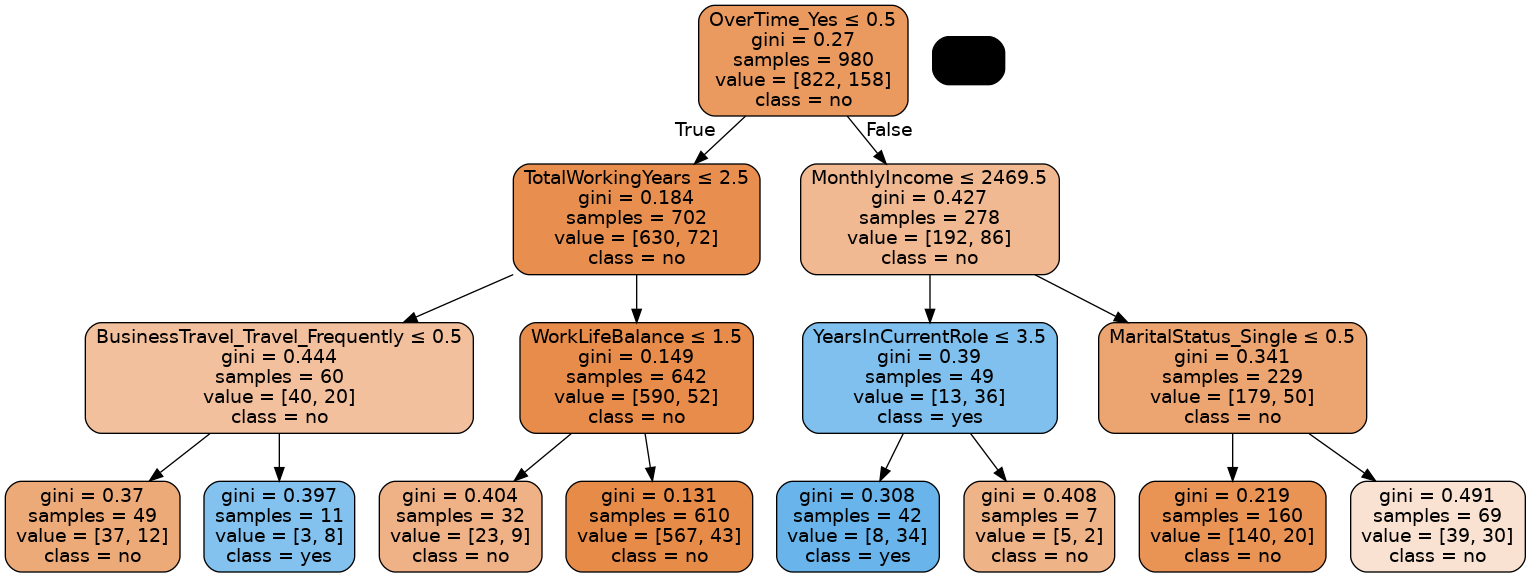

In [11]:
dot_data = StringIO()
export_graphviz(
    treeC,
    out_file=dot_data,
    filled=True,
    rounded=True,
    special_characters=True,
    feature_names=X.columns,
    class_names=["no", "yes"]
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

Самый важный признак — переработки, а если при работе сверхурочно сотрудник ещё и не очень много зарабатывает, занимает позицию меньше 3,5 лет, то вероятность оказаться в классе ушедших из компании возрастает.

Дерево явно смещено в сторону класса no, что соответствует распределению данных.

### Модель 2: логистическая регрессия

In [65]:
from sklearn.linear_model import LogisticRegression

logC = LogisticRegression(solver = "liblinear", max_iter=1000)
logC.fit(X_train, y_train)

logC.score(X_train, y_train), logC.score(X_test, y_test)

(0.8744897959183674, 0.8857142857142857)

Accuracy\. Train: 0\.874\. Test: 0\.886\. Модель не переобучена — на новых данных работает даже чуть лучше, чем на обучающих\.

In [68]:
log_pred = logC.predict(X_test)

metrics.confusion_matrix(y_test, log_pred)

array([[408,   3],
       [ 53,  26]])

- TN = 408 — корректно предсказали тех, кто не ушёл (больше, чем у дерева)
- FP = 3 — ошибочно предсказали, что они уйдут (меньше, чем у дерева)
- FN = 53 — пропустили сотрудников, которые на самом деле ушли (уже меньше, чем было у дерева, но всё ещё много)
- TP = 26 — корректно нашли ушедших (заметно большее количество, чем у дерева)

In [71]:
metrics.f1_score(y_test, log_pred, pos_label=True)

0.4814814814814815

F1\-score \(класс yes\) = 0\.481\. Значительно лучше, чем у дерева \(0\.211\), но есть куда стремиться\.

In [74]:
print("Decision Tree classification report:")
print(metrics.classification_report(y_test, tree_pred))

print("Logistic Regression classification report:")
print(metrics.classification_report(y_test, log_pred))

Decision Tree classification report:
              precision    recall  f1-score   support

       False       0.85      0.99      0.92       411
        True       0.62      0.13      0.21        79

    accuracy                           0.85       490
   macro avg       0.74      0.56      0.56       490
weighted avg       0.82      0.85      0.80       490

Logistic Regression classification report:
              precision    recall  f1-score   support

       False       0.89      0.99      0.94       411
        True       0.90      0.33      0.48        79

    accuracy                           0.89       490
   macro avg       0.89      0.66      0.71       490
weighted avg       0.89      0.89      0.86       490



**Дерево:**

- precision = 0.62: если модель предсказывает "Yes" (человек ушёл), то она часто права
- recall = 0.13: модель находит всего лишь 13% реально ушедших сотрудников
- f1 = 0.21
Модель почти всех определяет как "No".

**Логистическая регрессия:**
- precision = 0.90: намного лучше, чем у дерева
- recall = 0.33: модель находит 33% реально ушедших сотрудников, намного лучше
- f1 = 0.48

### Выводы:
- Модель логистической регрессии работает лучше, чем дерево решений, поэтому в качестве итоговой я бы выбрала её, но её качество всё равно не очень высокое (F1-score = 0.48)
- Несмотря на довольно высокое значение accuracy у обоих моделей, эта метрика не очень информативна, так как классы несбалансированы
- Модель дерева дала достаточно интересные для интерпретации результаты, хоть и с низким качеством

# Часть 5 \(Ансамбли\)

### Бэггинг

In [80]:
from sklearn.ensemble import BaggingClassifier
modelBag = BaggingClassifier(base_estimator=logC, n_estimators=100, random_state=7)

In [98]:
modelBag.fit(X_train, y_train)
modelBag.score(X_train, y_train), modelBag.score(X_test, y_test)

/root/venv/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


(0.8775510204081632, 0.8795918367346939)

In [128]:
metrics.f1_score(y_test, modelBag.predict(X_test), pos_label=True)

0.4587155963302753

Случайный лес:

In [89]:
from sklearn.ensemble import RandomForestClassifier
modelRF = RandomForestClassifier(n_estimators=50, max_features=10, max_depth=3)
modelRF.fit(X_train, y_train)
modelRF.score(X_train, y_train), modelRF.score(X_test, y_test)

(0.8612244897959184, 0.8469387755102041)

In [137]:
metrics.f1_score(y_test, modelRF.predict(X_test), pos_label=True)

0.13793103448275862

### Бустинг

AdaBoost:

In [92]:
from sklearn.ensemble import AdaBoostClassifier
modelAB = AdaBoostClassifier(base_estimator=logC, n_estimators=100)
modelAB.fit(X_train, y_train)
modelAB.score(X_train, y_train), modelAB.score(X_test, y_test)

/root/venv/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


(0.8673469387755102, 0.8795918367346939)

In [125]:
metrics.f1_score(y_test, modelAB.predict(X_test), pos_label=True)

0.4778761061946903

### Стекинг

Логистическая регрессия \+ AdaBoost

In [95]:
pred1_train = pd.DataFrame(modelAB.predict(X_train))
pred2_train = pd.DataFrame(logC.predict(X_train))
pred1_test = pd.DataFrame(modelAB.predict(X_test))
pred2_test = pd.DataFrame(logC.predict(X_test))

data_train = pd.concat([pred1_train, pred2_train], axis=1)
data_test = pd.concat([pred1_test, pred2_test], axis=1)

modelSt = LogisticRegression(solver = "liblinear")
modelSt.fit(data_train,y_train)
modelSt.score(data_train, y_train), modelSt.score(data_test, y_test)

(0.8744897959183674, 0.8836734693877552)

In [122]:
metrics.f1_score(y_test, modelSt.predict(data_test), pos_label=True)

0.4672897196261682

### Выводы:
- В качестве итоговой я бы выбрала модель логистической регрессии, так как её качество (0.886) не ниже, чем у ансамблей (+ у неё самая высокая F1-мера — 0.481), и интерпретировать такую модель намного проще
- Среди ансамблей лучше всего сработал стекинг (accuracy = 0.884), AdaBoost и бэггинг (где в обоих в качестве основы была использована модель логистической регрессии, accuracy = 0.880), у случайного леса качество ощутимо ниже всех (accuracy = 0.847, f1 = 0.14)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ff5c65e0-9edf-47b2-8d5a-439e7f5c1ece' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>